In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import data_analytics_lib as dal
import random

# Exercise 1

## Write a Python function to read in the data. The data file is named driving_clustering_data.txt. Plot the raw data for the distance feature and speeding features. Make the distance feature the independent value and the speeding feature the dependent value for the plot. Write a Python function that will take as inputs the raw feature data (distance and speed) and return the normalized data for each feature. Plot the normalized data for the distance feature and speeding features. Makethe normalized distance feature the independent value and the normalized speeding feature the dependent value for the plot.

In [45]:
def read_data(file):
    
    driver_id = []
    driving_feature = []
    speeding_feature = []
    
    with open(file, 'r') as f:
        
        data = f.readlines()
        
        for line in data[1:]:  # Skip the header line
            line = line.strip().split()
            driver_id.append(float(line[0]))
            driving_feature.append(float(line[1]))
            speeding_feature.append(float(line[2]))

    return driver_id, driving_feature, speeding_feature

driver_id, driving_feature, speeding_feature = read_data('/Users/244213/Desktop/DataAnalytics/Stats/driving_clustering_data.txt')


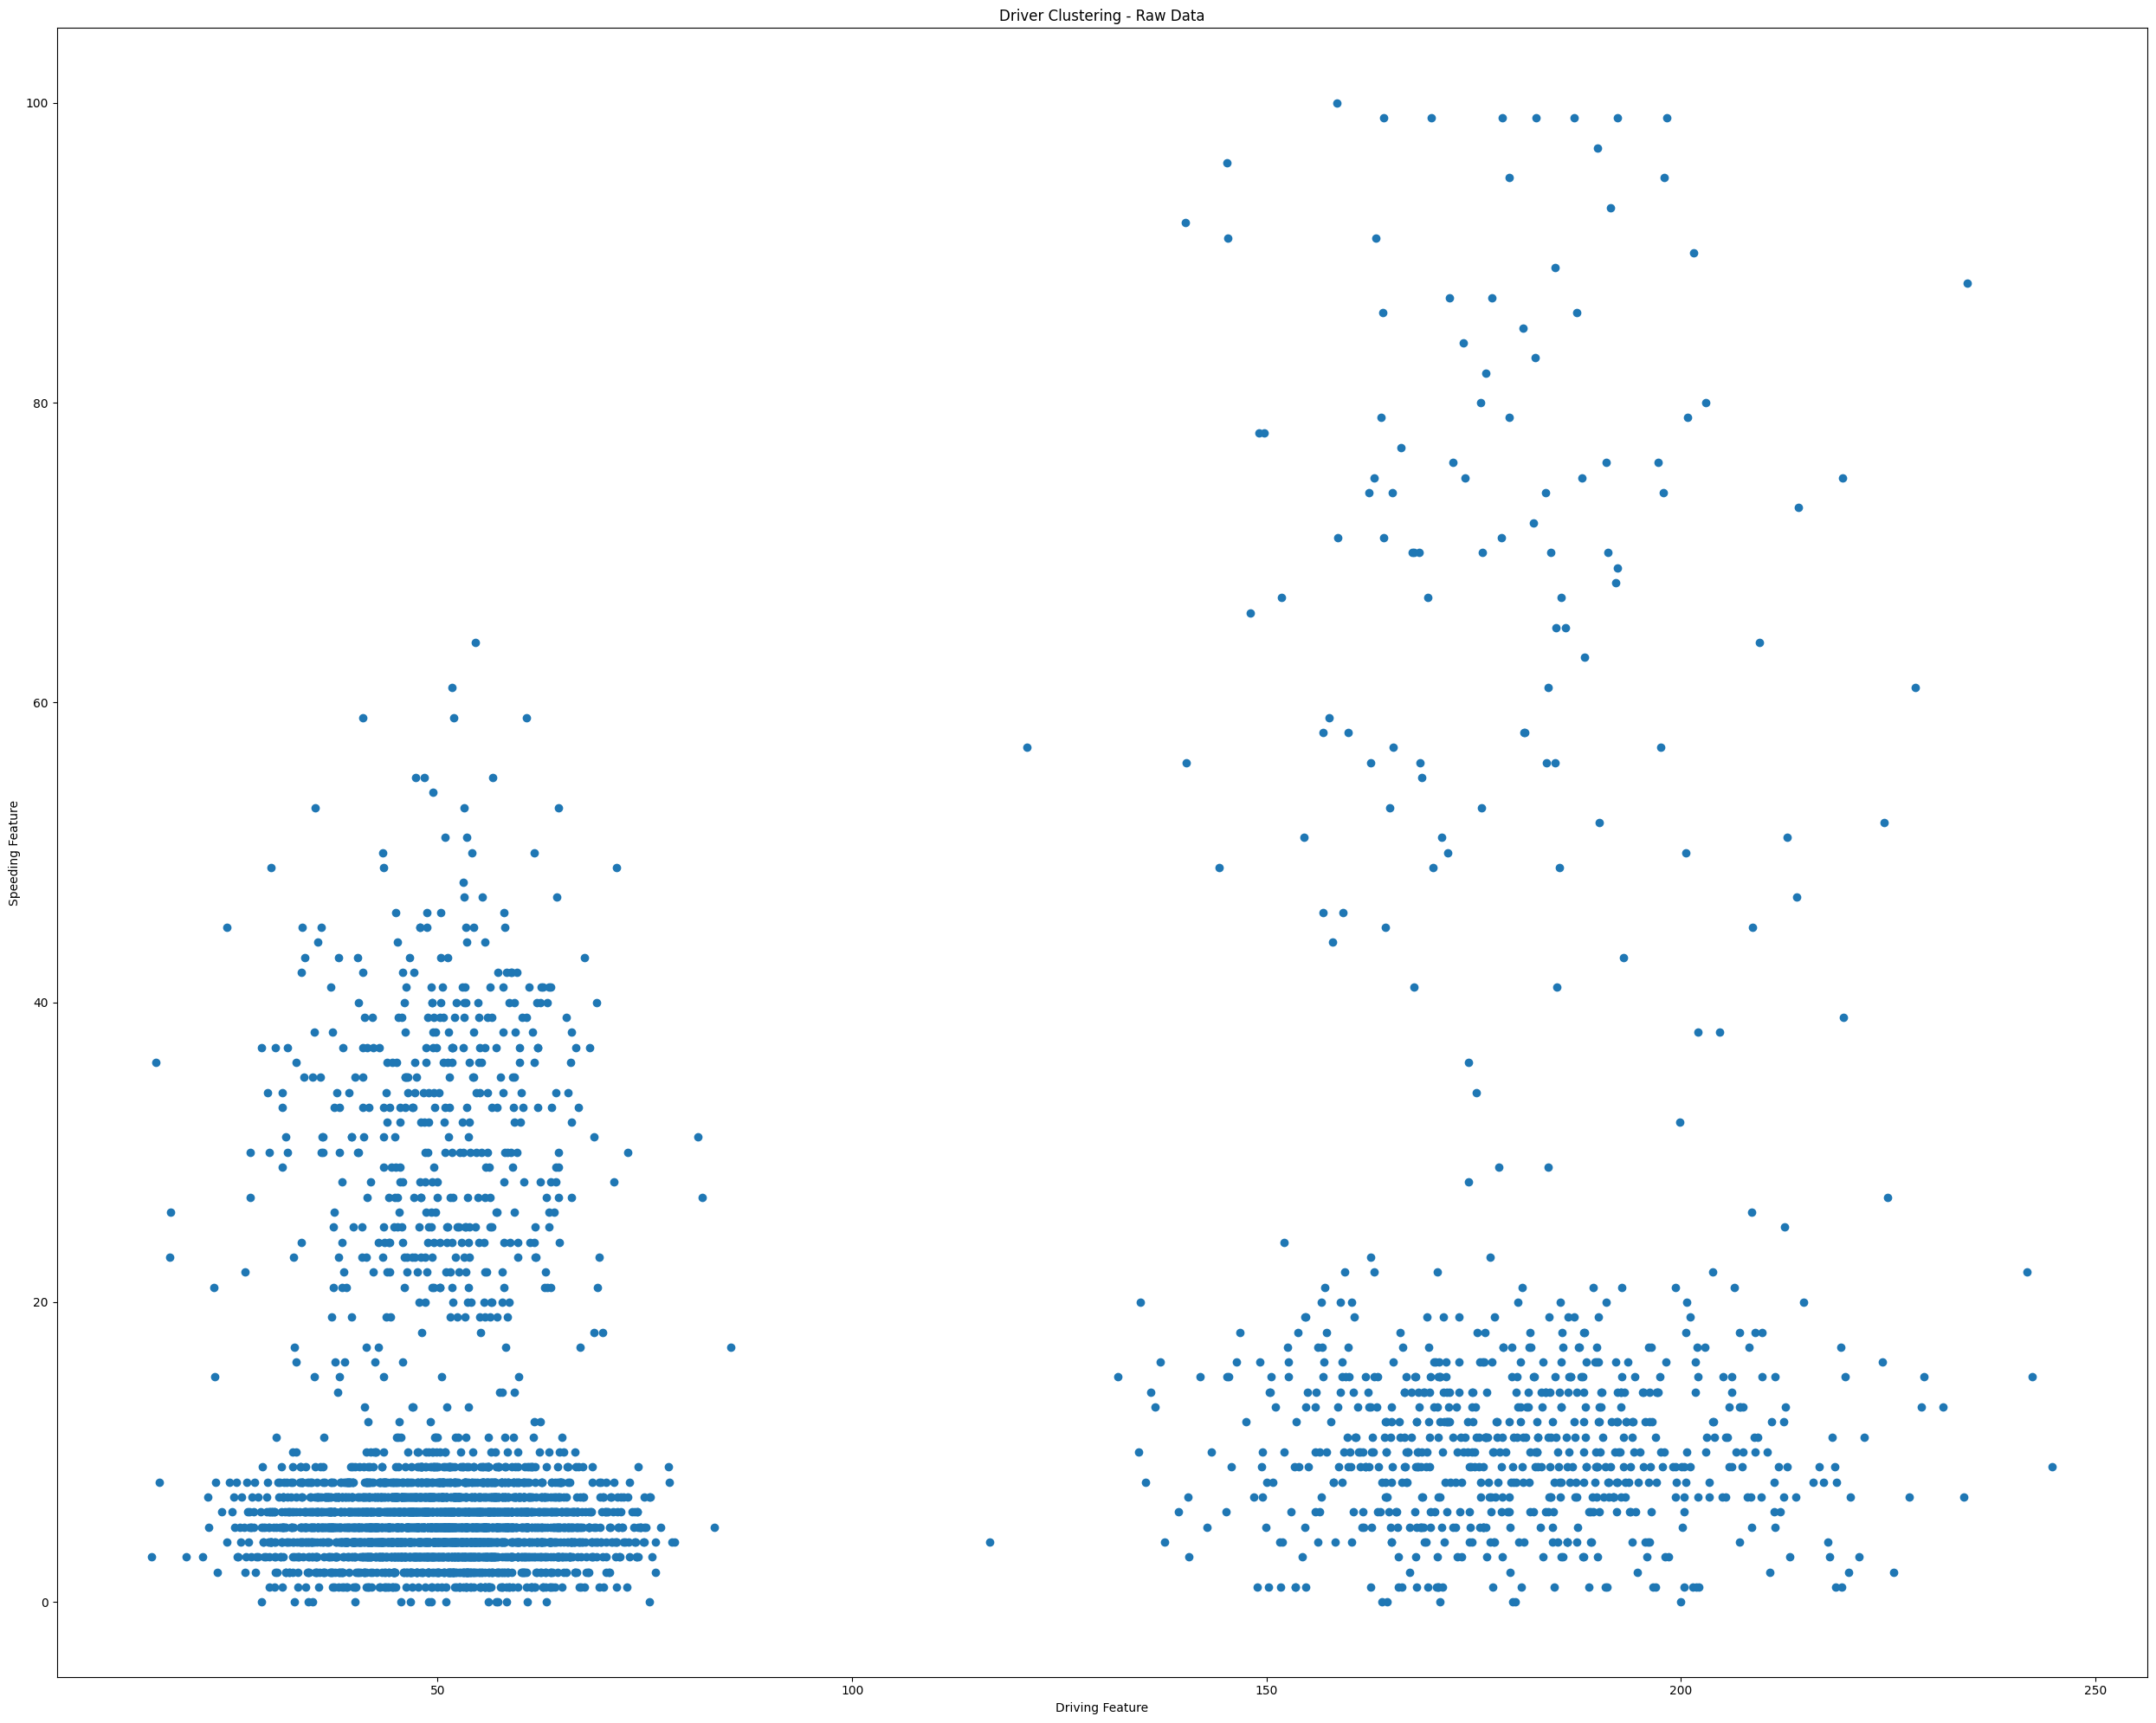

In [46]:
plt.figure(figsize=(25, 20))
plt.scatter(driving_feature, speeding_feature)
plt.xlabel('Driving Feature')
plt.ylabel('Speeding Feature')
plt.title('Driver Clustering - Raw Data')
plt.tight_layout()
plt.show()

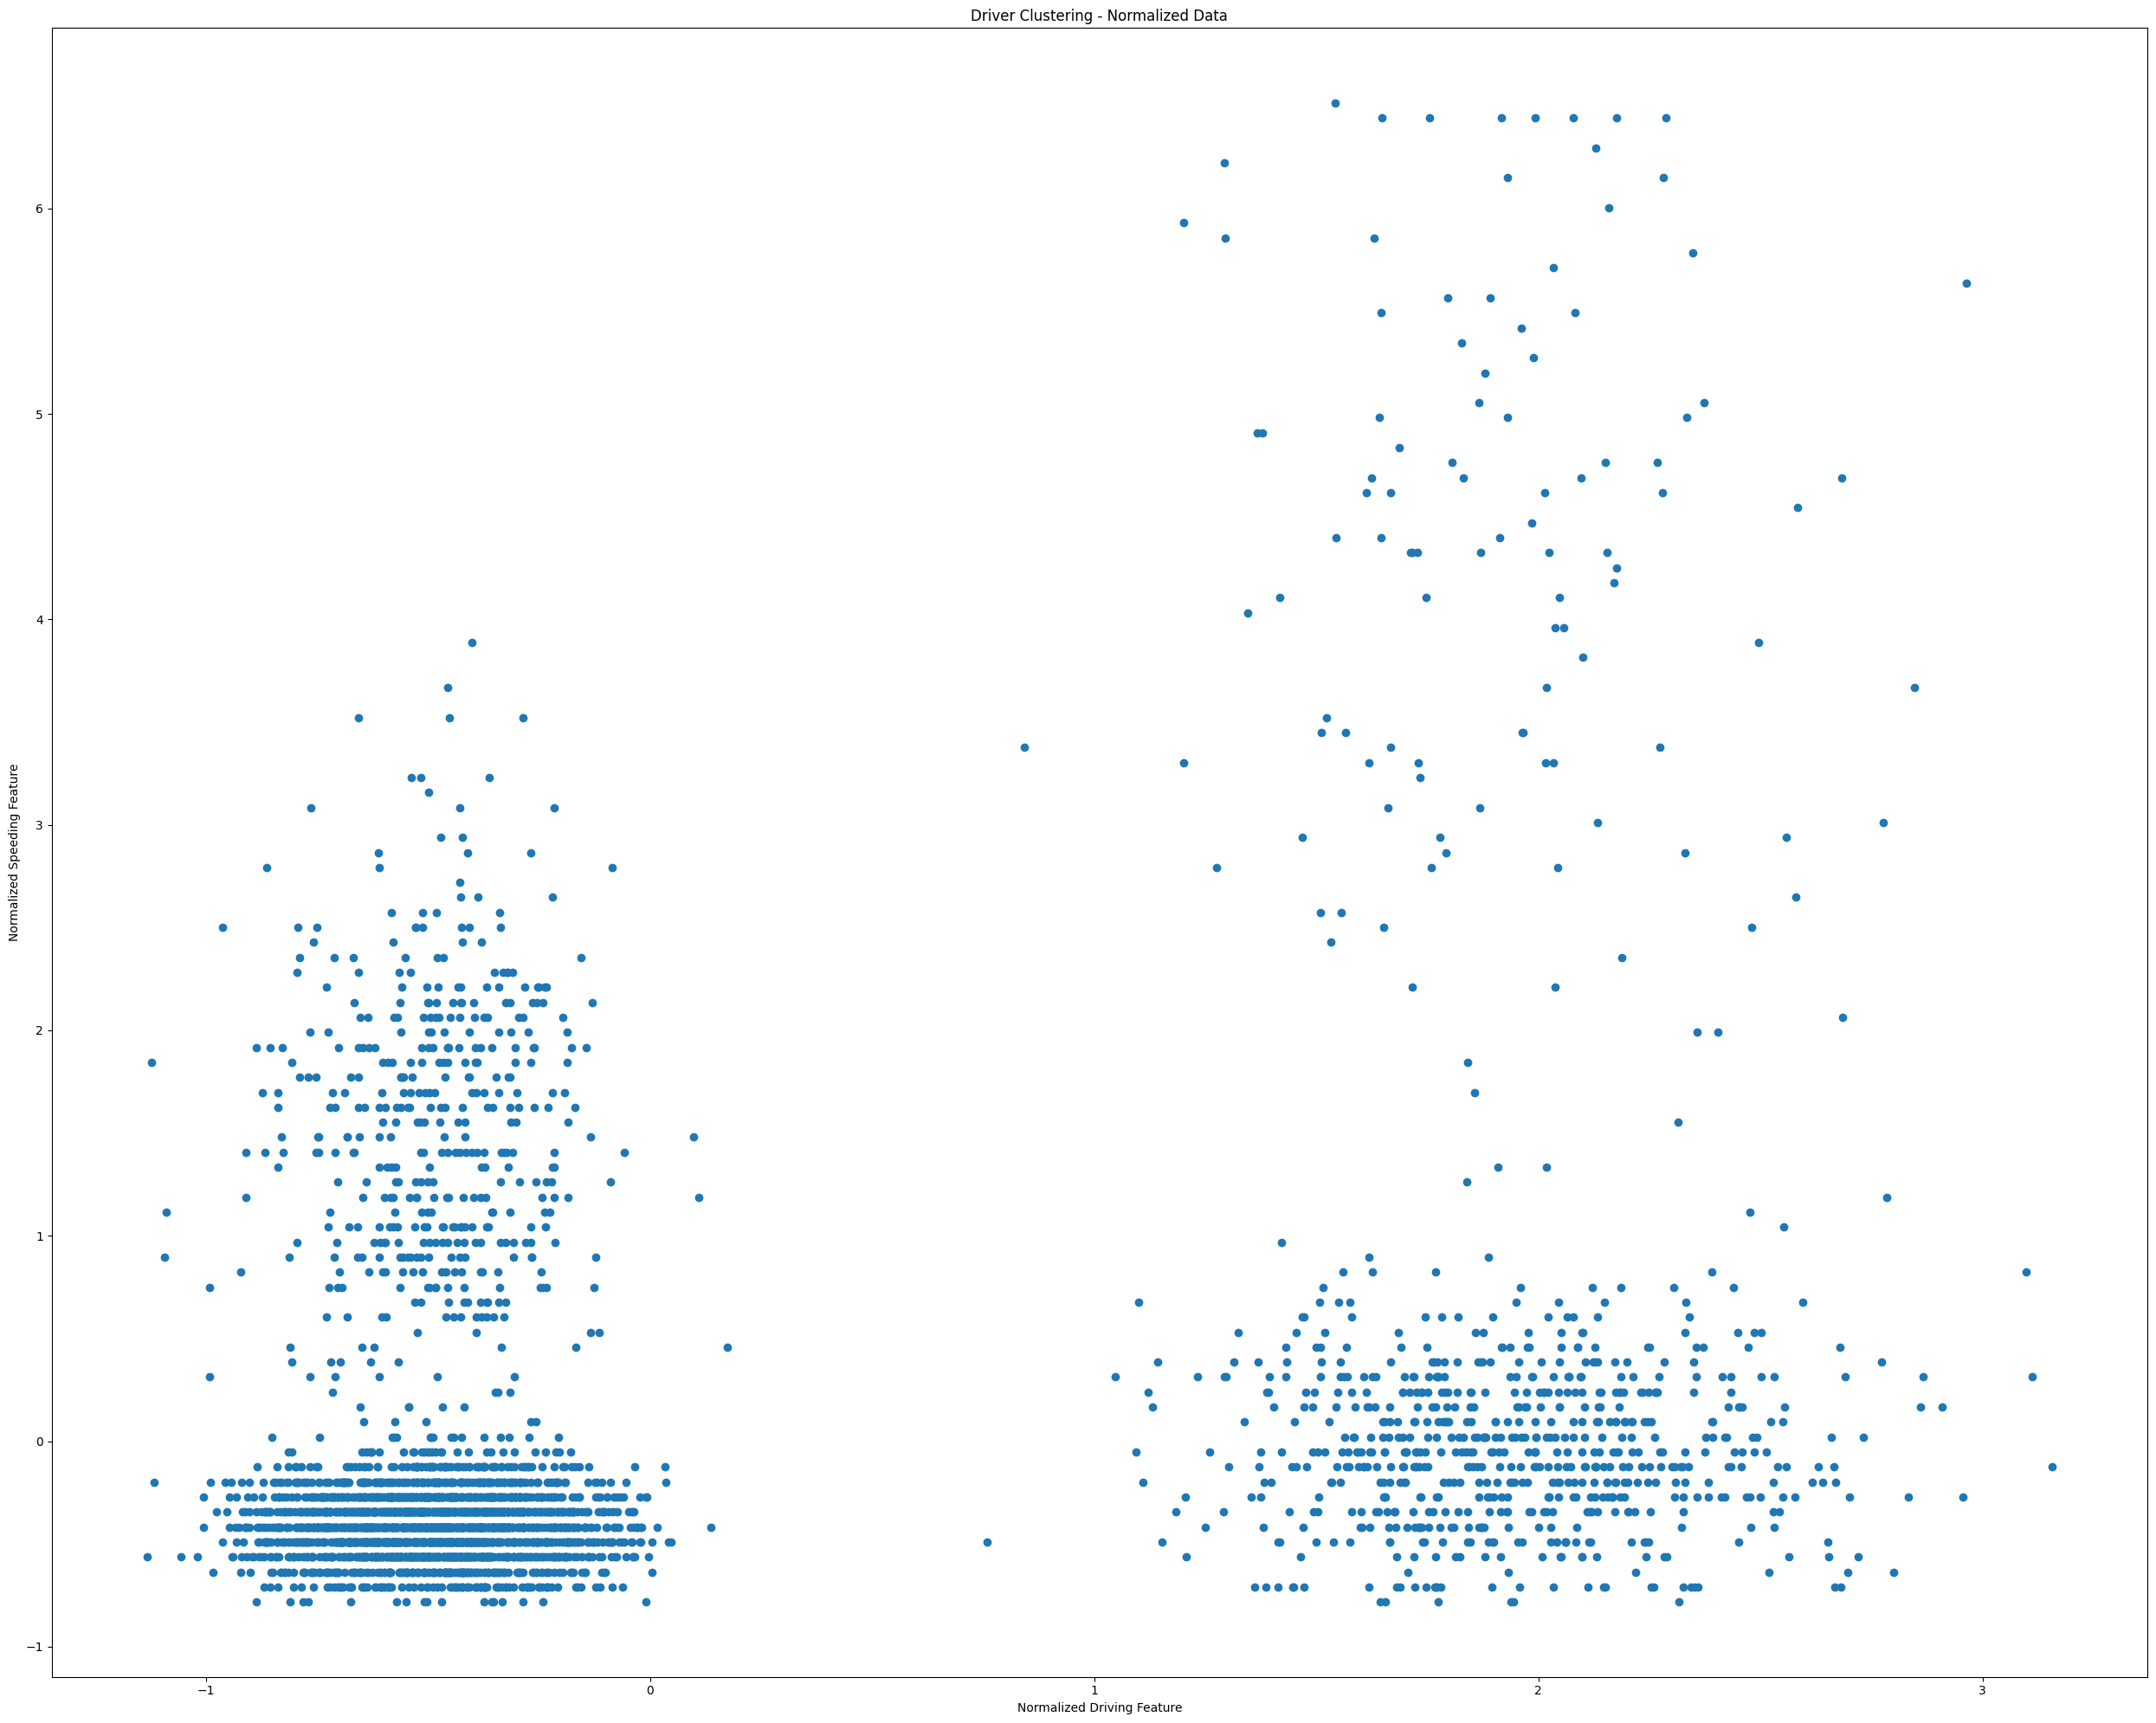

In [47]:
def k_means_normalize_data(feature1, feature2):
    feature1 = np.array(feature1)
    feature2 = np.array(feature2)

    normalized_feature1 = []
    normalized_feature2 = []  

    for i in range(len(feature1)):
        normalized_feature1.append((feature1[i] - np.mean(feature1)) / np.std(feature1))
    for i in range(len(feature2)):
        normalized_feature2.append((feature2[i] - np.mean(feature2)) / np.std(feature2))

    return normalized_feature1, normalized_feature2

normalized_driving_feature, normalized_speeding_feature = k_means_normalize_data(driving_feature, speeding_feature)

plt.figure(figsize=(25, 20))
plt.scatter(normalized_driving_feature, normalized_speeding_feature)
plt.xlabel('Normalized Driving Feature')
plt.ylabel('Normalized Speeding Feature')
plt.title('Driver Clustering - Normalized Data')
plt.tight_layout()
plt.show()


# Exercise 2

Initial centroids: [(-0.5, 1.0), (2.0, 1.0)]


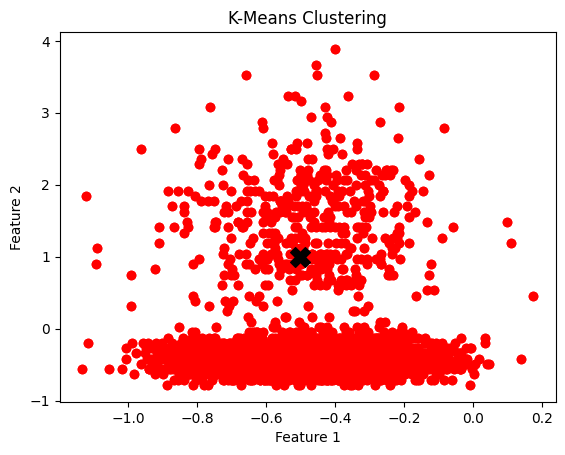

Updated centroids: [array([-0.48620443, -0.13805162]), array([1.9448177, 0.5522065])]


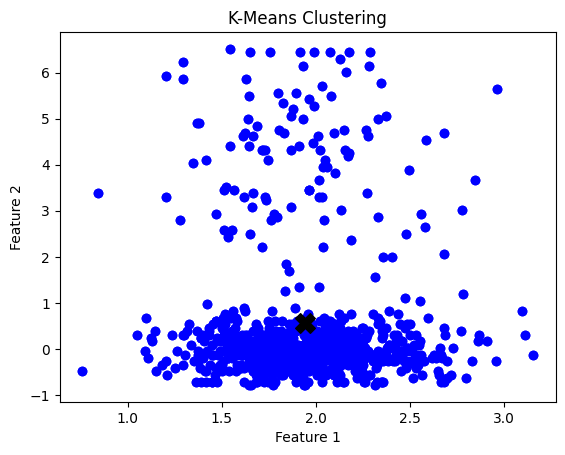

Updated centroids: [array([-0.48620443, -0.13805162]), array([1.9448177, 0.5522065])]


In [ ]:
def k_means_clustering_algorithm_2d(feature1, feature2):
    # Colors for cluster 
    colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple', 'brown']
    
    # Initialize number of iterations
    max_iterations = int(input("Enter the maximum number of iterations: "))
    
    # Initialize centroids and clusters by asking user for input
    k = int(input("Enter the number of clusters (k): "))
    clusters = {}

    centroids = []
    for i in range(k):
        x = float(input(f"Enter the x-coordinate of centroid {i+1}: "))
        y = float(input(f"Enter the y-coordinate of centroid {i+1}: "))
        centroids.append((x, y))


    print(f"Initial centroids: {centroids}")
    
    
    
    for i in range(max_iterations):
        
        # Assigning clusters through distance to centroid
        for j in range(len(feature1)):
            points = np.array([feature1[j], feature2[j]])
            
            distances = []
            
            for centroid in centroids:
                dist = np.linalg.norm(points - np.array(centroid))
                distances.append(dist)

            closest_centroid_index = np.argmin(distances) + 1

            if closest_centroid_index not in clusters:
                
                clusters[closest_centroid_index] = []
                
            clusters[closest_centroid_index].append(points)

        # Plotting the clusters
        
        for cluster_index, points in clusters.items():
            if points:
                cluster_points = np.array(points)

                # Cluster Plot
                plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[cluster_index - 1])

                # Centroid Plot
                plt.scatter(centroids[cluster_index - 1][0], centroids[cluster_index - 1][1], color='black', marker='X', s= 200)
                
            plt.title("K-Means Clustering")
            plt.xlabel("Feature 1")
            plt.ylabel("Feature 2")
            plt.show()

        # Update centroids for each iteration
        for i in range(1, k + 1):

                if i in clusters:
                    new_centroid = np.mean(np.array(clusters[i]), axis=0)
                    centroids[i - 1] = new_centroid

        print(f"Updated centroids: {centroids}")
        
        
    return clusters
       
clusters = k_means_clustering_algorithm_2d(normalized_driving_feature, normalized_speeding_feature)

def cluster_stats(cluster):
    cluster_size = len(cluster)
    cluster_mean = np.mean(cluster)
    cluster_median = np.median(cluster)
    cluster_std = np.std(cluster)
    cluster_min = np.min(cluster)
    cluster_max = np.max(cluster)

    cluster_stats = {
        "size": cluster_size,
        "mean": cluster_mean,
        "median": cluster_median,
        "std": cluster_std,
        "min": cluster_min,
        "max": cluster_max
    }

    return cluster_stats
